# Q2: Customer segmentation with K-Means

In this notebook, I cluster customers using behavioral signals and then map the groups into 2D with PCA so the segment shapes are easier to read.

In [25]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")


In [26]:
# Task 1: Data Preparation
df = pd.read_csv("../data/q2_customers.csv")
feature_cols = df.columns.tolist()

# Scale all features (K-Means relies on distance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

df.head()


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


### Why I’m scaling first
K-Means is distance-based, so raw feature scale matters a lot. Without scaling, variables like `annual_spend` would dominate distance calculations and skew clusters. Standardizing keeps each feature on a comparable footing.

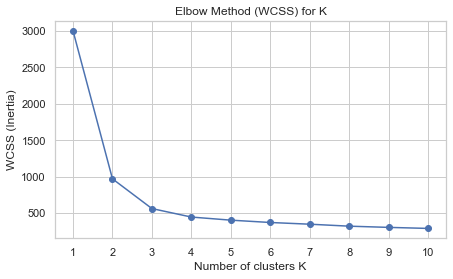

Chosen elbow K: 3


In [27]:
# Task 2: Choosing K with Elbow Method
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), wcss, marker="o")
plt.title("Elbow Method (WCSS) for K")
plt.xlabel("Number of clusters K")
plt.ylabel("WCSS (Inertia)")
plt.xticks(list(K_range))
plt.show()

# Identify elbow programmatically (max distance from line)
ks = np.array(list(K_range))
y = np.array(wcss)

# Line between first and last points
x1, y1 = ks[0], y[0]
x2, y2 = ks[-1], y[-1]

numerator = np.abs((y2 - y1) * ks - (x2 - x1) * y + x2 * y1 - y2 * x1)
denominator = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
dist = numerator / denominator


k_opt = int(ks[np.argmax(dist)])
print("Chosen elbow K:", k_opt)


### Choosing K
Using the elbow curve plus the max-distance heuristic, `K=3` is the best compromise. Beyond that, inertia still drops, but the gains are much smaller.

In [28]:
# Task 3: K-Means Clustering
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels

# Cluster centroids in original feature scale for readability
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_orig, columns=feature_cols)
centroids_df.insert(0, "cluster", [f"Cluster {i}" for i in range(k_opt)])

centroids_df.round(3)


,cluster,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,Cluster 0,24.676,14847.371,14.341,558.971,9.076,2.112
1,Cluster 1,56.770,89413.333,2.527,5530.545,105.358,7.515
2,Cluster 2,40.388,43340.733,8.194,2021.685,35.188,4.424


### Segment readout (business view)
From the centroids:

- **Cluster 0**: younger and active (frequent visits, recent activity), but smaller baskets.
- **Cluster 1**: high-value but likely drifting away (large spend/baskets, long time since last visit).
- **Cluster 2**: middle segment with average behavior and room to improve visit frequency.

If I had to map actions quickly: retain Cluster 0, reactivate Cluster 1, and nudge frequency for Cluster 2.

In [29]:
# Task 4: Dimensionality Reduction with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pc_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

# Feature loadings (components)
loadings_df = pd.DataFrame(pca.components_, columns=feature_cols, index=["PC1", "PC2"])
loadings_df.round(4)


Explained variance ratio:
[0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.4116,0.4215,-0.4104,0.4120,0.3786,0.4140
PC2,-0.2594,-0.0333,0.2083,-0.1954,0.9112,-0.1405


### What PC1/PC2 mean here
The loadings suggest:

- **PC1** mostly captures customer value/intensity (spend, basket size, category breadth) against visit frequency.
- **PC2** is largely recency-driven (`days_since_last_visit`).

Since PC1 explains much more variance than PC2, the strongest cluster separation is value-pattern driven, with recency acting as a secondary axis.

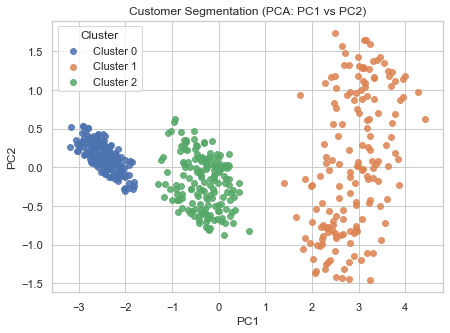

In [30]:
# Task 5: Cluster Visualization (PC1 vs PC2)
plot_df = df.copy()
plot_df[["PC1", "PC2"]] = pc_df[["PC1", "PC2"]]

plt.figure(figsize=(7, 5))
for c in sorted(plot_df["cluster"].unique()):
    sub = plot_df[plot_df["cluster"] == c]
    plt.scatter(sub["PC1"], sub["PC2"], label=f"Cluster {c}", alpha=0.85, s=35)

plt.title("Customer Segmentation (PCA: PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", loc="best")
plt.show()
